# Chapter 2. 큐비트와 양자 게이트

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 1**

## 학습 목표
- 단일 큐비트 상태를 진폭과 Bloch 좌표로 다루기
- Pauli 게이트(X, Y, Z)와 회전 게이트(RX, RY, RZ)의 효과 직접 확인
- Hadamard로 중첩, CNOT으로 얽힘을 만들고 Bell 상태 분석
- 회로 행렬을 추출해 게이트의 동작을 검증

In [8]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt

## 2.1 큐비트 상태를 직접 살펴보기
`qml.state()`로 회로 적용 후의 상태 벡터를 얻을 수 있다. 복소 진폭의 절댓값 제곱이 측정 확률이다.

In [9]:
dev = qml.device('default.qubit', wires=1)

@qml.qnode(dev)
def init_state():
    # 초기 상태 |0> — 아무 게이트도 적용하지 않음
    return qml.state()

state = init_state()
print('초기 상태 |ψ> =', state)
print('확률:', np.abs(state) ** 2)

초기 상태 |ψ> = [1.+0.j 0.+0.j]
확률: [1. 0.]


## 2.2 Pauli 게이트의 작용
Pauli-X는 비트플립(NOT), Pauli-Z는 위상플립이다.

In [10]:
@qml.qnode(dev)
def apply_X():
    qml.PauliX(wires=0)  # |0> → |1>
    return qml.state()

@qml.qnode(dev)
def apply_Z_after_H():
    qml.Hadamard(wires=0)  # |0> → (|0>+|1>)/√2
    qml.PauliZ(wires=0)    # → (|0> - |1>)/√2
    return qml.state()

print('X|0> =', apply_X())
print('ZH|0> =', np.round(apply_Z_after_H(), 4))

X|0> = [0.+0.j 1.+0.j]
ZH|0> = [ 0.7071+0.j -0.7071+0.j]


## 2.3 회전 게이트와 Bloch 구
회전 게이트 `R_y(θ)`로 만들어진 상태는 다음과 같다.

$$R_y(\theta)|0\rangle = \cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle$$

각도를 0부터 2π까지 변화시키며 측정 확률을 그려본다.

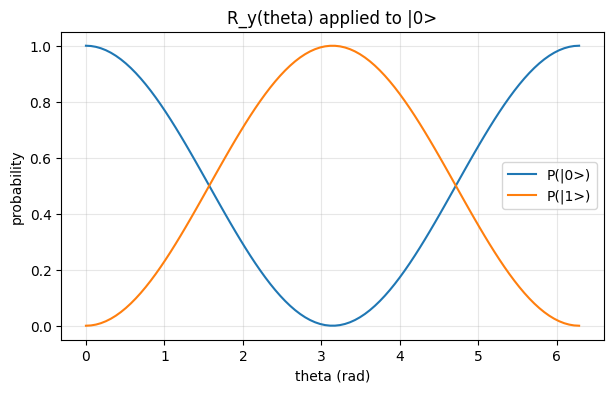

In [11]:
@qml.qnode(dev)
def ry_circuit(theta):
    qml.RY(theta, wires=0)
    return qml.probs(wires=0)

thetas = np.linspace(0, 2 * np.pi, 100)
# 각 theta에 대한 P(|0>), P(|1>) 계산
probs_arr = np.array([ry_circuit(t) for t in thetas])

plt.figure(figsize=(7, 4))
plt.plot(thetas, probs_arr[:, 0], label='P(|0>)')
plt.plot(thetas, probs_arr[:, 1], label='P(|1>)')
plt.xlabel('theta (rad)')
plt.ylabel('probability')
plt.title('R_y(theta) applied to |0>')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

두 확률은 `cos²(θ/2)`과 `sin²(θ/2)` 곡선을 그린다. 이는 회전 게이트가 큐비트 상태를 연속적으로 보간(interpolate)한다는 뜻이다.

## 2.4 게이트의 행렬 추출
PennyLane은 회로의 유니터리 행렬을 직접 계산해줄 수 있다. 이를 통해 게이트의 정확한 동작을 검증할 수 있다.

In [12]:
# Hadamard 게이트의 행렬
H_matrix = qml.matrix(qml.Hadamard)(wires=0)
print('H =')
print(np.round(H_matrix, 4))

# 회전 게이트의 행렬 (θ=π/3)
RY_matrix = qml.matrix(qml.RY(np.pi / 3, wires=0))
print('\nR_y(π/3) =')
print(np.round(RY_matrix, 4))

H =
[[ 0.7071  0.7071]
 [ 0.7071 -0.7071]]

R_y(π/3) =
[[ 0.866+0.j -0.5  -0.j]
 [ 0.5  +0.j  0.866+0.j]]


## 2.5 2큐비트와 얽힘 — Bell 상태 4종 만들기
Hadamard + CNOT 조합에 초기 상태를 다르게 주면 4가지 Bell 상태를 모두 만들 수 있다.

In [13]:
dev2 = qml.device('default.qubit', wires=2)

@qml.qnode(dev2)
def bell(prep_x_0, prep_x_1):
    # 초기 비트 준비 (0 또는 1)
    qml.RX(prep_x_0 * np.pi, wires=0)
    qml.RX(prep_x_1 * np.pi, wires=1)
    # Bell 회로
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.state()

labels = ['|Φ+>', '|Ψ+>', '|Φ->', '|Ψ->']
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
for label, (a, b) in zip(labels, inputs):
    s = np.round(bell(a, b), 3)
    print(f'{label}: {s}')

|Φ+>: [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]
|Ψ+>: [0.+0.j    0.-0.707j 0.-0.707j 0.+0.j   ]
|Φ->: [0.-0.707j 0.+0.j    0.+0.j    0.+0.707j]
|Ψ->: [ 0.   -0.j -0.707-0.j  0.707-0.j  0.   +0.j]


각 입력 비트 조합이 서로 다른 Bell 상태로 매핑된다. 4개의 Bell 상태는 두 큐비트의 4차원 공간에서 직교 기저(orthonormal basis)를 이룬다.

## 2.6 얽힘의 증거 — 분리 가능성 검사
Bell 상태는 두 큐비트의 곱으로 분해할 수 없다 (entanglement). 확인을 위해 partial trace로 한쪽 큐비트의 reduced density matrix를 본다.

In [14]:
@qml.qnode(dev2)
def bell_phi_plus():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.density_matrix(wires=[0])

rho_0 = bell_phi_plus()
print('큐비트 0의 reduced density matrix:')
print(np.round(rho_0, 3))
print('\n순수 상태이면 trace(rho²) = 1, 얽혀있으면 < 1')
purity = np.trace(rho_0 @ rho_0).real
print(f'purity = {purity:.3f}')

큐비트 0의 reduced density matrix:
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

순수 상태이면 trace(rho²) = 1, 얽혀있으면 < 1
purity = 0.500


Bell 상태에서 한쪽 큐비트만 보면 완전한 혼합 상태(purity=0.5)가 된다. 전체 상태는 순수하지만 부분만 보면 정보가 완전히 사라진 것처럼 보이는 것, 이것이 얽힘의 본질이다.

## 2.7 정리
- 단일 큐비트 상태는 복소 진폭 2개로 표현된다.
- Pauli/회전 게이트로 큐비트를 회전시킨다.
- `qml.matrix`로 게이트의 행렬을 직접 추출할 수 있다.
- Hadamard + CNOT으로 4개의 Bell 상태를 만들 수 있다.
- `qml.density_matrix`로 얽힘을 정량적으로 측정할 수 있다.